# K-means-segmentering av abonnentbeteende med PROC FASTCLUS

## Sammanfattning

Den här notebooken segmenterar en syntetisk bas på 100 mobilabonnenter i beteendekluster med `PROC FASTCLUS`, Base SAS k-means-klustringsprocedur. Sju användningsfunktioner standardiseras till z-poäng med `PROC STDIZE` så att variabler med stor magnitud (röstminuter, SMS-antal) inte dominerar det euklidiska avståndet, varefter `PROC FASTCLUS` anpassar tre kluster. Proceduren rapporterar RMS-avvikelsen inom varje kluster, en total R-kvadrat och pseudo-F som mäter hur väl segmenteringen separerar basen (här en total R-kvadrat på 0,575 och pseudo-F på 65,75), och skriver en poängsatt tabell med en `CLUSTER`-etikett på varje abonnent. Vi slår ihop dessa etiketter med data i ursprunglig skala, profilerar personorna och lämnar över tilldelningarna till nedströms aktivering.

## Datakällor

| Dataset | Beskrivning | Rader | Nyckelvariabler |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Syntetisk månatlig beteendeögonblicksbild för en mobiloperatörs abonnentbas, genererad inline med `call streaminit` / `rand()`. Tre latenta beteendetyper (datatung, röstcentrerad, låg användning) blandas med brus. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominell), `region` (nominell) |

# K-means-segmentering av abonnentbeteende

**Bransch:** Telekommunikation &nbsp;|&nbsp; **Procedur:** `PROC FASTCLUS` (Base SAS k-means-klustring)

Mobiloperatörer har abonnenter vars månatliga beteende -- dataaptit, röstvanor, spenderande och supportfriktion -- faller in i ett fåtal igenkännbara mönster. Att upptäcka dessa mönster gör att verksamheten kan skräddarsy retentionsåtgärder, sälja rätt paket och förvärva liknande kunder. Den här notebooken bygger en beteendesegmentering från början till slut: generera en realistisk abonnentögonblicksbild, standardisera funktionerna, låt `PROC FASTCLUS` anpassa klustren, poängsätt varje abonnent och profilera segmenten till handlingsbara personor. `PROC FASTCLUS` är utformad för exakt denna disjunkta k-means-uppgift och skalar till mycket stora baser genom att gå igenom data i en enda passage istället för att bygga en fullständig avståndsmatris.

## 1. Generera en syntetisk abonnentbas

Vi simulerar 100 abonnenter hämtade från tre latenta beteendearketyper -- **datatunga strömmare**, **röstcentrerade traditionalister** och **lätt-/lågförbrukare** -- och blandar sedan in brus så att gränserna blir suddiga (som de är i verkligheten). Varje abonnent har också två kategoriska attribut, `data_plan` och `region`, som vi använder senare för att *profilera* segmenten. Fröet gör datat reproducerbart.

In [1]:
/* -----------------------------------------------------------
   Syntetisk ögonblicksbild av mobilabonnenter (100 rader).
   Tre latenta beteendearketyper + brus, plus två
   kategoriska attribut för segmentprofilering.
   ----------------------------------------------------------- */
data subscribers;
    CALL streaminit(20260531);

    LÄNGD data_plan $12 region $8;

    GÖR subscriber_id = 100001 TILL 100100;

        /* latent arketyp: 1=mycket data, 2=röst, 3=låg användning */
        u = rand('uniform');
        OM      u < 0.38 SÅ archetype = 1;
        ANNARS OM u < 0.70 SÅ archetype = 2;
        ANNARS                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        OM archetype = 1 SÅ GÖR;             /* datatung strömmare */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        SLUT;
        ANNARS OM archetype = 2 SÅ GÖR;        /* röstcentrerad */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        SLUT;
        ANNARS GÖR;                              /* låg användning */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        SLUT;

        OM planpick = 1 SÅ data_plan = 'Kontantkort';
        ANNARS OM planpick = 2 SÅ data_plan = 'Efterskott';
        ANNARS data_plan = 'Obegränsat';

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        OM region_pick = 1 SÅ region = 'Norr';
        ANNARS OM region_pick = 2 SÅ region = 'Söder';
        ANNARS OM region_pick = 3 SÅ region = 'Öster';
        ANNARS region = 'Väster';

        /* avrunda till prydlig rapporteringsprecision */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        UTDATA;
    SLUT;

    BEHÅLL subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
KÖR;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Undersök funktionsfördelningarna

Innan klustring, titta på skalan och spridningen för varje beteendefunktion. De vitt skilda enheterna -- gigabyte, minuter, dollar, antal -- är precis varför vi standardiserar intervallindata innan klustring; annars skulle variabler med stor magnitud som `voice_minutes` dominera det euklidiska avstånd som `PROC FASTCLUS` minimerar.

                                                  The MEANS Procedure

 Variable         Label                           N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Kundlängd (månader)           100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Månatlig data (GB)            100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Röstminuter                   100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Antal SMS                     100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Internationella minuter       100  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


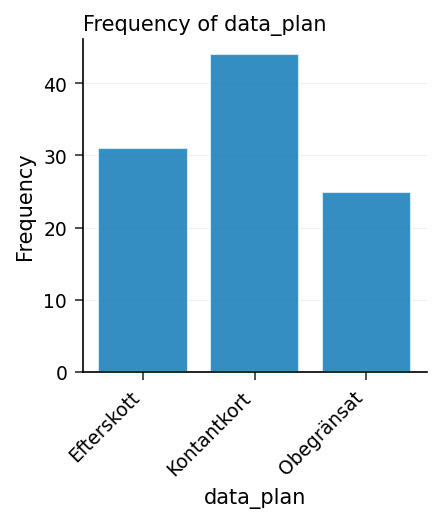

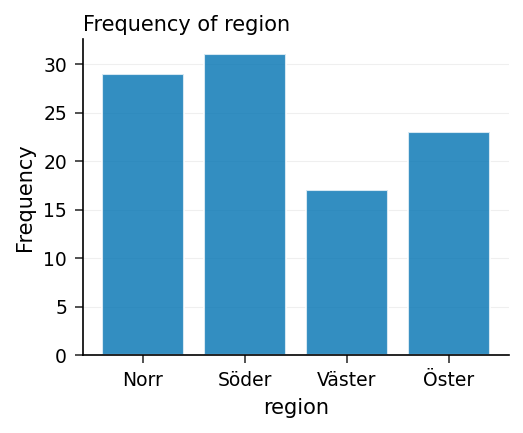

In [2]:
/* Sammanfattande statistik för klustringsvariablerna */
PROCEDUR MEDELVÄRDEN data=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETIKETT tenure_months="Kundlängd (månader)"
          monthly_data_gb="Månatlig data (GB)"
          voice_minutes="Röstminuter"
          sms_count="Antal SMS"
          intl_minutes="Internationella minuter"
          arpu="ARPU ($)"
          support_calls="Supportsamtal";
KÖR;

/* Frekvens för de två kategoriska indatavariablerna */
PROCEDUR FREKVENSER data=subscribers;
    TABLES data_plan region / nocum;
    ETIKETT data_plan="Abonnemangstyp" region="Region";
KÖR;

## 3. Standardisera funktionerna till z-poäng

`PROC FASTCLUS` minimerar euklidiskt avstånd, så en variabel mätt i hundratals minuter skulle överskugga en som mäts i ensiffriga gigabyte. `PROC STDIZE` med `METHOD=STD` skalar om varje intervallfunktion till medelvärde 0 och standardavvikelse 1, vilket ger varje beteende samma vikt i avståndet. De kategoriska kolumnerna och identifieraren passerar oförändrade igenom så att vi kan profilera klustren på deras ursprungliga skala efteråt.

In [3]:
/* z-poäng-standardisera intervallfunktionerna; id och kategoriska variabler passerar oförändrade */
PROCEDUR stdize data=subscribers out=subs_std METHOD=std;
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
KÖR;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Anpassa k-means-segmenteringen

Vi anpassar tre segment med `PROC FASTCLUS`. `MAXCLUSTERS=3` sätter *k*; `MAXITER=20` låter klustercentren itereras till konvergens. Proceduren rapporterar en **klustersammanfattning** (storlek och RMS-avvikelse inom klustret per kluster), **statistik för variabler** (den R-kvadrat varje funktion bidrar med), en **total R-kvadrat** och **pseudo-F** som mäter hur rent de tre klustren separerar basen, samt **klustermedelvärden** på den standardiserade skalan. `OUT=scored` skriver tillbaka indataraderna med en `CLUSTER`-etikett och `DISTANCE` från varje abonnent till dess klusterfrö.

In [4]:
/* k-means-anpassning på de standardiserade funktionerna: 3 segment. */
PROCEDUR FASTCLUS data=subs_std maxclusters=3 MAXITER=20 out=scored;
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETIKETT tenure_months="Kundlängd (månader)"
          monthly_data_gb="Månatlig data (GB)"
          voice_minutes="Röstminuter"
          sms_count="Antal SMS"
          intl_minutes="Internationella minuter"
          arpu="ARPU ($)"
          support_calls="Supportsamtal";
KÖR;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Koppla segmentetiketter till data i ursprunglig skala

Den poängsatta tabellen innehåller de standardiserade funktionerna; för profilering vill vi beskriva klustren i verkliga gigabyte, minuter och dollar. Vi slår ihop `CLUSTER`-etiketten tillbaka på den ursprungliga `subscribers`-tabellen via `subscriber_id`, och ställer sedan den första frågan marknadsföring alltid ställer: *hur stort är varje segment?*

                                                   The FREQ Procedure

Segment    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


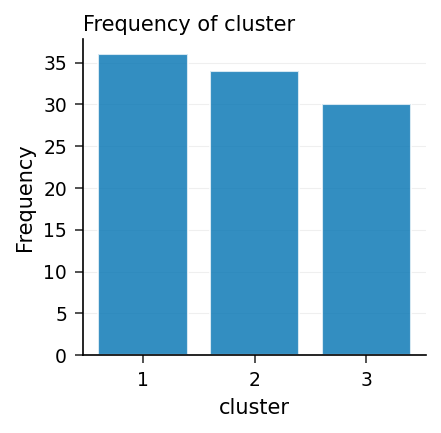

In [5]:
/* för tillbaka klusteretiketten till data i ursprunglig skala */
PROCEDUR SORTERA data=scored(keep=subscriber_id cluster distance) out=clus_assign;
    EFTER subscriber_id;
KÖR;
PROCEDUR SORTERA data=subscribers out=subs_sorted;
    EFTER subscriber_id;
KÖR;
data profile;
    SAMMANFOGA subs_sorted clus_assign;
    EFTER subscriber_id;
KÖR;

/* Hur många abonnenter hamnade i varje segment? */
PROCEDUR FREKVENSER data=profile;
    TABLES cluster / nocum;
    ETIKETT cluster="Segment";
KÖR;

## 6. Profilera segmenten

Kluster-ID:n är meningslösa tills vi beskriver *beteendet* inuti varje kluster. Att beräkna medelvärdet av de ursprungliga (icke-standardiserade) funktionerna per `CLUSTER` avslöjar personan bakom varje segment -- vem strömmar, vem pratar, vem knappt använder nätet -- och den kategoriska mixen visar vilka abonnemang och regioner som koncentreras i varje segment.

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months Kundlängd (månader)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                                Analysis Variable : monthly_data_gb Månatlig data (GB)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                     Analysis Variable : voice_minutes Röstminuter

        Segment           N Obs           Mean
        --------------------------------------
        1 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


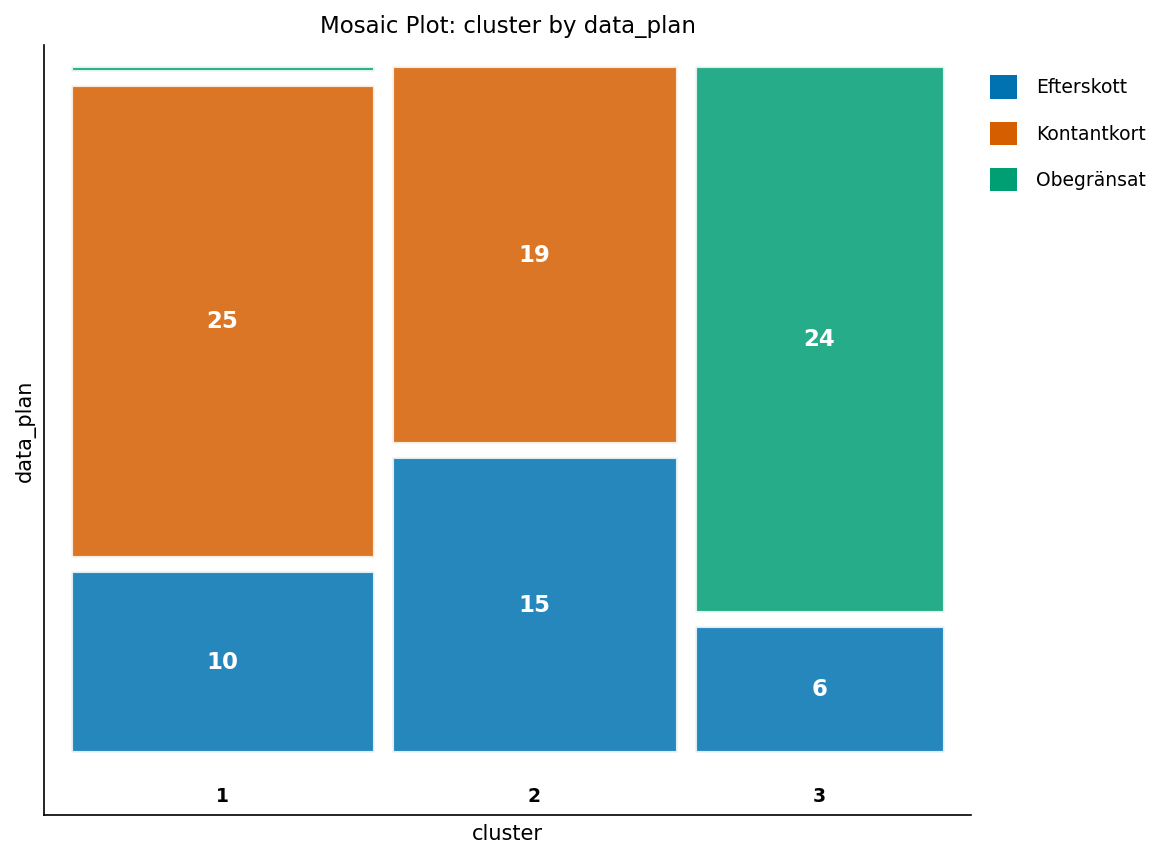

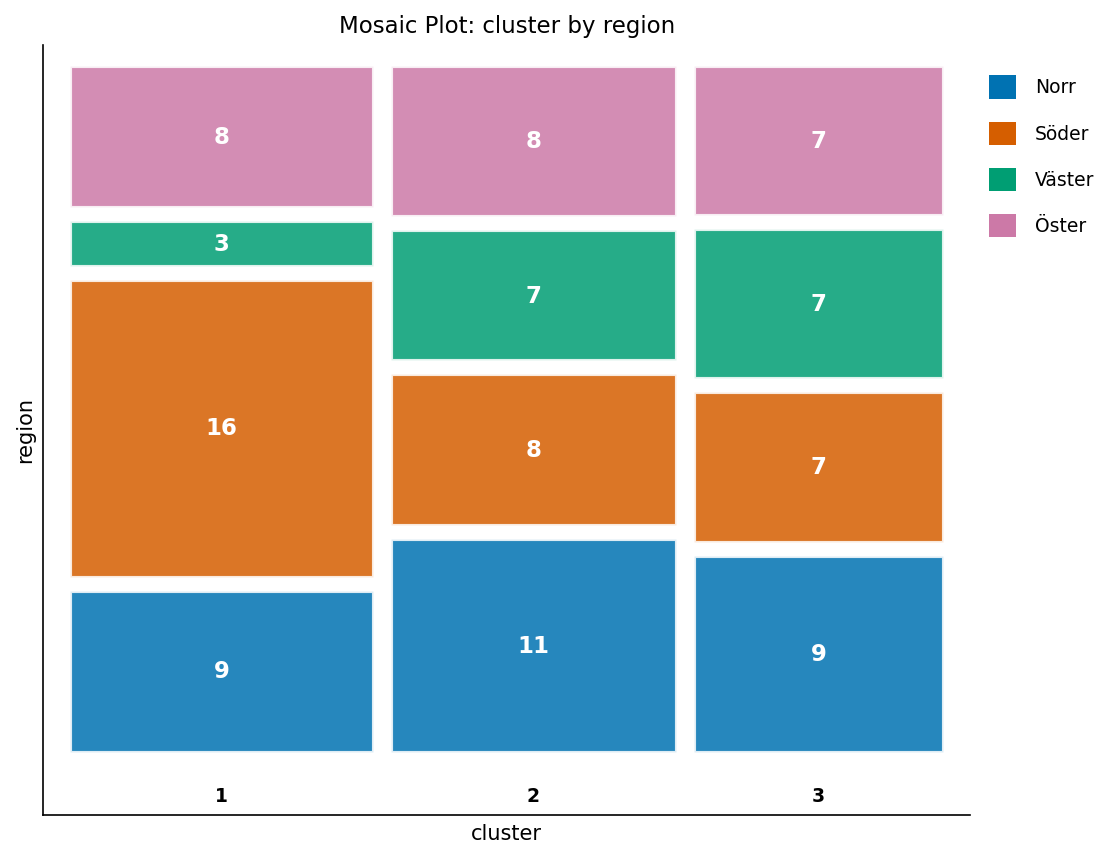

In [6]:
/* Beteendeprofil: medelvärde för varje funktion per segment */
PROCEDUR MEDELVÄRDEN data=profile n mean maxdec=1;
    KLASS cluster;
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETIKETT cluster="Segment"
          tenure_months="Kundlängd (månader)"
          monthly_data_gb="Månatlig data (GB)"
          voice_minutes="Röstminuter"
          sms_count="Antal SMS"
          intl_minutes="Internationella minuter"
          arpu="ARPU ($)"
          support_calls="Supportsamtal";
KÖR;

/* Kategorisk mix inom varje segment */
PROCEDUR FREKVENSER data=profile;
    TABLES cluster * data_plan / norow nopercent;
    TABLES cluster * region    / norow nopercent;
    ETIKETT cluster="Segment" data_plan="Abonnemangstyp" region="Region";
KÖR;

## 7. Visualisera segmenten

En bild gör segmenteringen konkret. Vi plottar dataaptit mot röstanvändning, färgad efter segment, och lägger till ett boxplot av ARPU per segment så att intäktshistorien blir tydlig på en gång.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


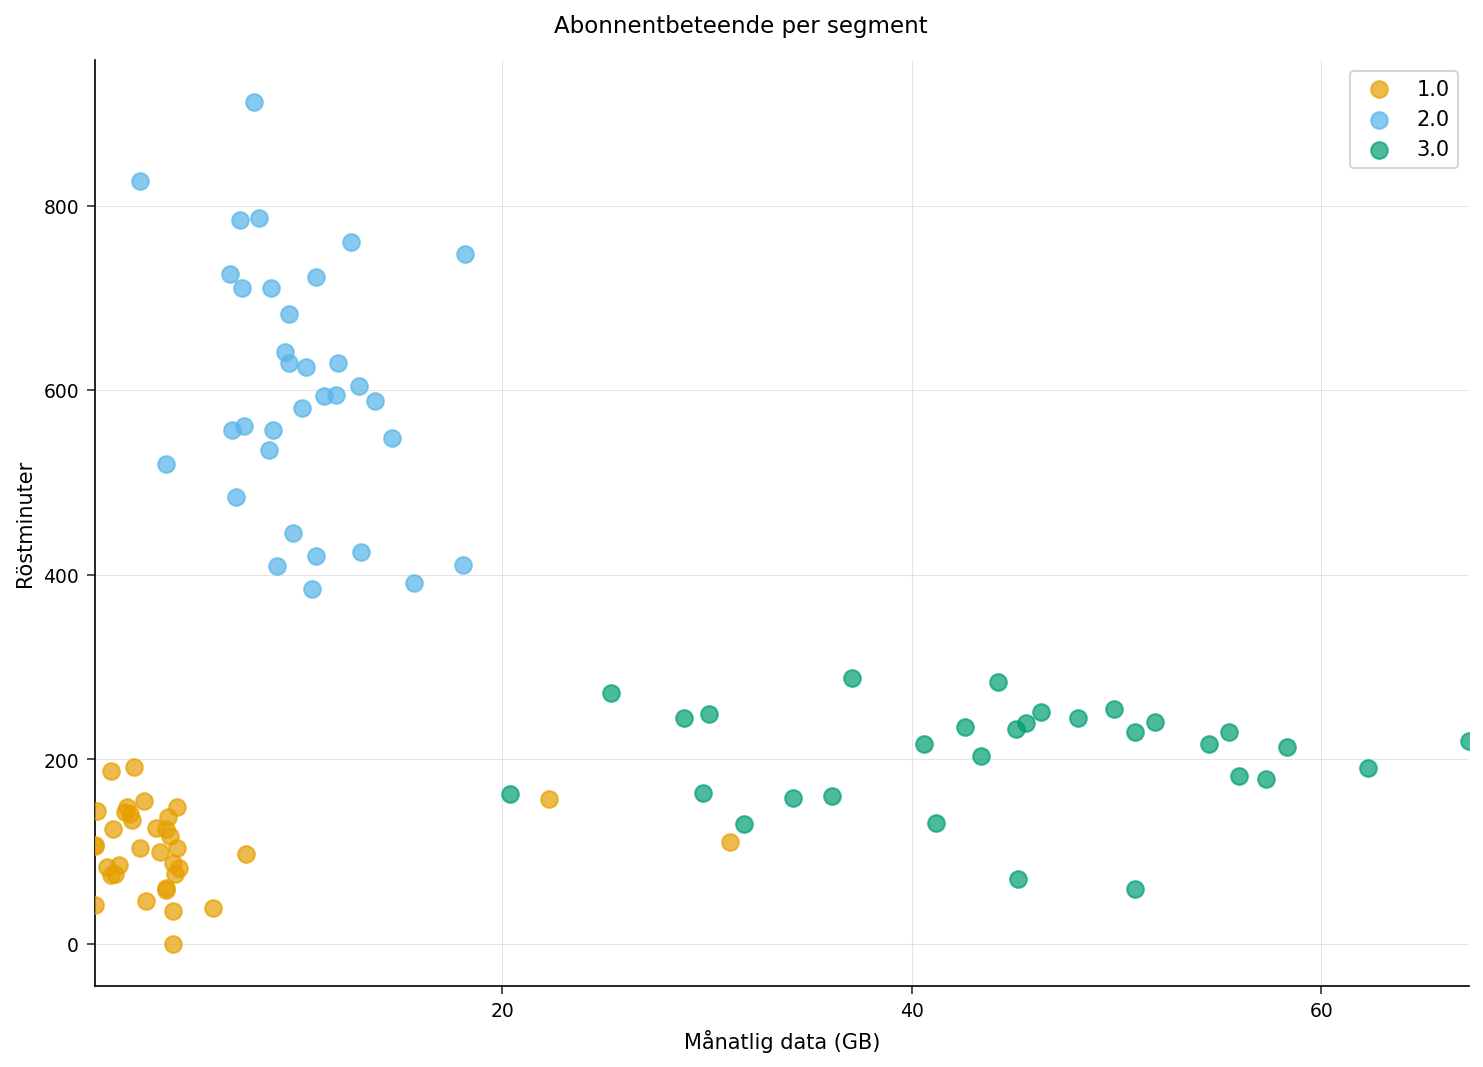

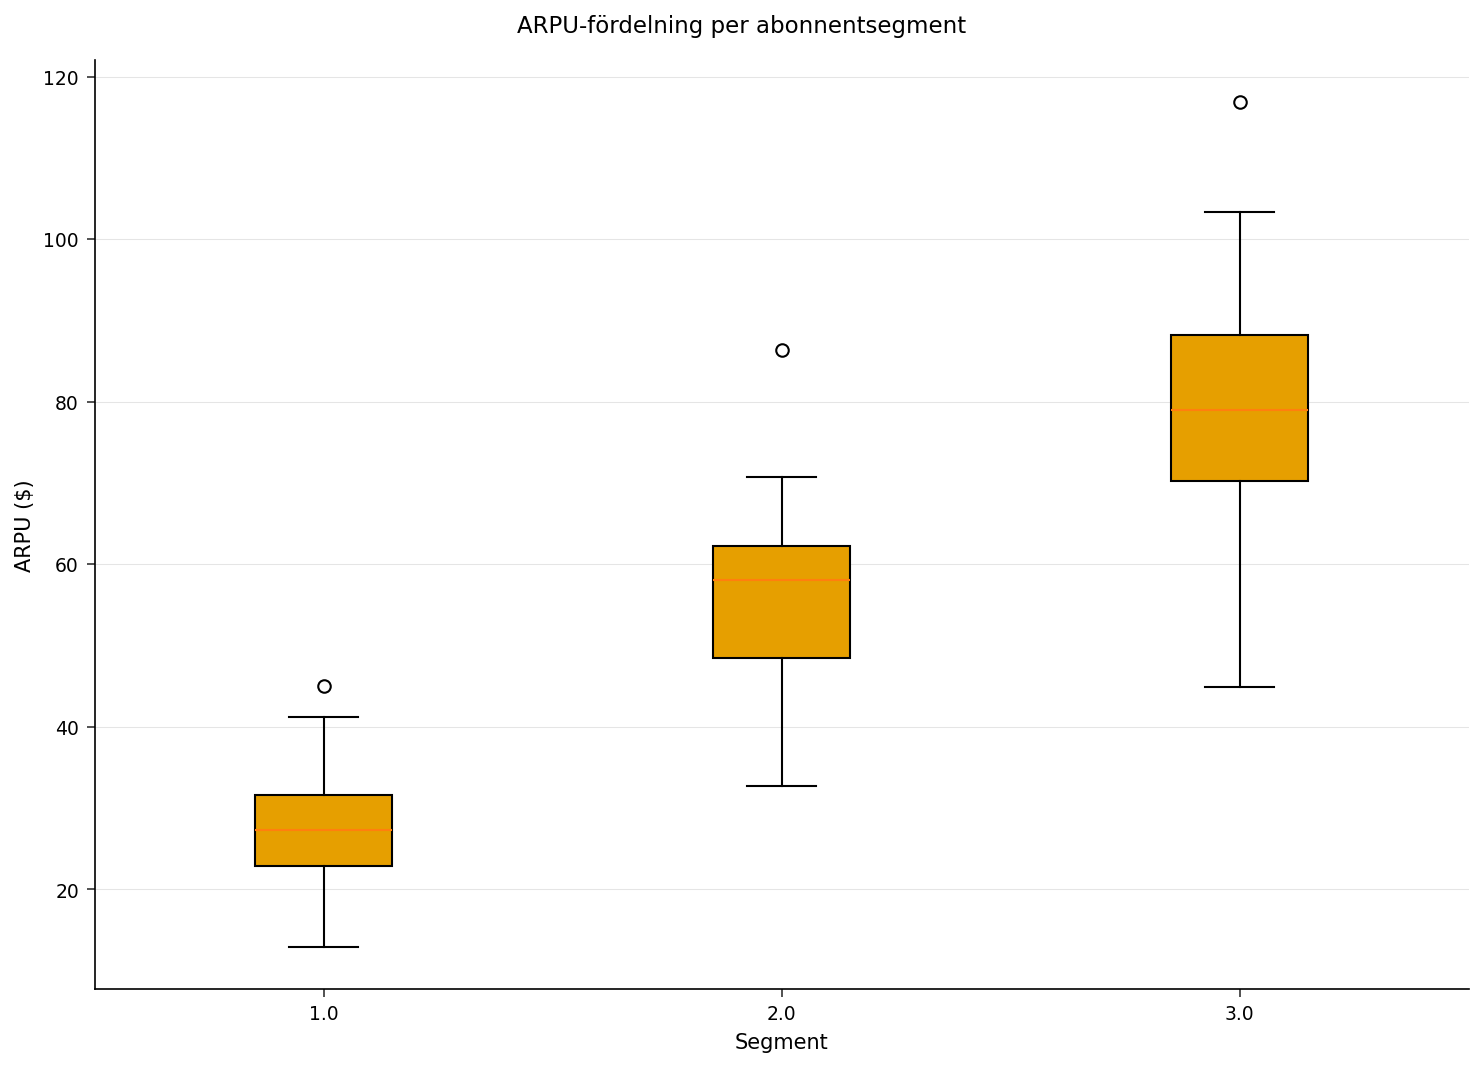

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Beteendekarta: data mot röst, färgad efter segment */
PROCEDUR SGPLOT data=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / group=cluster
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS label="Månatlig data (GB)" grid;
    YAXIS label="Röstminuter"     grid;
    TITEL "Abonnentbeteende per segment";
KÖR;

/* Intäktsfördelning per segment */
PROCEDUR SGPLOT data=profile;
    VBOX arpu / category=cluster;
    XAXIS label="Segment";
    YAXIS label="ARPU ($)" grid;
    TITEL "ARPU-fördelning per abonnentsegment";
KÖR;

## 8. Exportera de poängsatta segmenten

Slutligen, lämna över tilldelningarna till nedströms CRM- och kampanjsystem. Vi behåller identifieraren, klusteretiketten och de viktigaste beteendefälten.

In [8]:
/* Bevara segmenttilldelningarna för aktivering */
data subscriber_segments;
    STÄLL_IN profile;
    BEHÅLL subscriber_id cluster tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
KÖR;

PROCEDUR SKRIV data=subscriber_segments(obs=10) noobs label;
    TITEL "Exempel på poängsatta abonnentsegment";
    ETIKETT subscriber_id="Abonnent-ID" cluster="Segment"
          tenure_months="Kundlängd (månader)" monthly_data_gb="Månatlig data (GB)"
          voice_minutes="Röstminuter" arpu="ARPU ($)"
          data_plan="Abonnemangstyp" region="Region";
KÖR;

                                         Exempel på poängsatta abonnentsegment                                          

Abonnent-ID  Segment    Kundlängd (månader)   Månatlig data (GB)   Röstminuter  ARPU ($)  Abonnemangstyp   Region
     100001        1                     30                  2.3           104        28  Kontantkort     Söder
     100002        2                      8                 10.2           581     57.78  Kontantkort     Väster
     100003        2                      8                 10.7           385     55.66  Efterskott      Norr
     100004        2                     68                  7.4           561     70.68  Kontantkort     Norr
     100005        3                     18                 45.6           239     63.85  Obegränsat      Norr
     100006        3                     10                 30.1           249     88.33  Obegränsat      Öster
     100007        1                     62                  0.7            83     21.26  Kont


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Tolkning av resultaten

`PROC FASTCLUS` återfann tre rena, väl separerade segment. Anpassningen är solid: den **totala R-kvadraten är 0,575** och **pseudo-F är 65,75**, vilket innebär att de tre klustren förklarar cirka 58 % av den totala variationen i de standardiserade funktionerna. Separationen drivs nästan uteslutande av de beteendesignaler vi bryr oss om -- `voice_minutes` (R-kvadrat 0,858), `monthly_data_gb` (0,844) och `arpu` (0,771) bär segmenteringen, medan `tenure_months` (0,000) och `support_calls` (0,193) bidrar med nästan ingenting, vilket bekräftar att *hur* en abonnent använder nätet -- inte hur länge de varit kund -- definierar personorna.

De tre segmenten mappas direkt till marknadsföringsklara personor, profilerade här på den ursprungliga (icke-standardiserade) skalan:

| Segment | n (andel) | Signaturbeteende | Abonnemangsmix | Persona | Rekommenderad åtgärd |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30 %) | Högst data: **44,4 GB/mån**, topputgift **79,1 USD ARPU**, måttlig röst (205 min) | 24/30 **Obegränsat** | **Datatunga strömmare** | Skydda och uppsälj: snabbare nivåer, innehållspaket, enhetsuppgraderingar |
| **2** | 34 (34 %) | Högst röst **603 min/mån**, **214 SMS**, **106 int. min**, medelutgift **55,9 USD ARPU** | Kontantkort + Efterskott, **inget Obegränsat** | **Röstcentrerade traditionalister** | Internationella tillägg, familje-/röstpaket, lojalitetsbelöningar |
| **1** | 36 (36 %) | Lägst förbrukning: **4,0 GB**, 104 röstmin, lägst utgift **28,0 USD ARPU** | 25/36 **Kontantkort** | **Lätt-/lågförbrukare** | Rätt-storlek abonnemang, autogironudgar, lågkostnads-datastartpaket för att öka användningen |

Abonnemangsmixen bekräftar den beteendemässiga läsningen: det datatunga segmentet ligger till övervägande del på **Obegränsat**-abonnemang (24 av 30), det röstcentrerade segmentet har **inga** Obegränsat-abonnenter, och lågförbrukarsegmentet är mestadels **Kontantkort** (25 av 36). Region, däremot, är jämnt spridd över alla tre segment -- geografi är ingen beteendemässig drivkraft här, vilket i sig är ett användbart fynd för kampanjinriktning.

**Varför `PROC FASTCLUS` passar detta problem.** Den kör disjunkt k-means genom att gå igenom data i en enda passage istället för att materialisera en fullständig avståndsmatris, så samma program som segmenterade dessa 100 abonnenter skalar till mycket stora baser. Att standardisera med `PROC STDIZE` först tog bort enhetsskaleobiaset över gigabyte, minuter och dollar så att varje beteende bidrog lika mycket till det euklidiska avståndet; R-kvadrat-diagnostiken berättade sedan *vilka* funktioner som faktiskt drev delningen. Den poängsatta utdatan -- en `CLUSTER`-etikett på varje abonnent -- går rakt in i aktiveringspipelines och sluter cirkeln från rått beteende till riktat erbjudande.

---

<div style="font-size:11px;color:#9e9e9e">Denna notebook tillhandahålls endast i demonstrationssyfte. Datat är syntetiskt och resultaten utgör inte affärsrådgivning.</div>